/var/folders/1h/8kw0jbt134d6sgxbnf23qrhr0000gn/T/ipykernel_59336/461558801.py:60: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  web_search = TavilySearchResults(max_results=2)
/Users/utsabchakraborty/Documents/Edureka_May2026/Backup_LG/venv/lib/python3.14/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


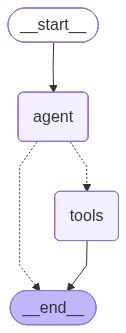


USER QUERY: Who is MS Dhoni?
================================ Human Message =================================

Who is MS Dhoni?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (call_exi36XF4rSH1RM3Lon6utFBR)
 Call ID: call_exi36XF4rSH1RM3Lon6utFBR
  Args:
    query: MS Dhoni
================================= Tool Message =================================
Name: wikipedia

Page: MS Dhoni
Summary: Mahendra Singh  Dhoni ([məˈɦeːnd̪ɾə ˈsɪŋɡʱ ˈd̪ʱoːniː] ; born 7 July 1981) is an Indian professional cricketer who plays as a right-handed batter and a wicket-keeper. Widely regarded as one of the most prolific wicket-keeper batsmen and captains, he represented the Indian cricket team and was the captain of the team in limited overs formats from 2007 to 2017 and in Test cricket from 2008 to 2014. Dhoni has captained the most international matches and is the most successful Indian captain. He has led India to victory in the 2007 ICC World T

In [5]:
"""
=============================================================
FILE 3 — MULTI-TOOL AGENT
=============================================================

CONCEPTS TAUGHT:
-----------------
1. Multiple tools
2. Semantic tool routing
3. External knowledge tools
4. Tavily web search
5. Wikipedia search
6. Arxiv search
7. Math tools
8. LLM tool selection
9. Agent architecture limitations
10. One-step agent limitations

KEY IDEA:
---------
The LLM chooses which tool to use
based on the user request.

"""

# =============================================================
# STEP 1 — LOAD ENV VARIABLES
# =============================================================

import os
from dotenv import load_dotenv

load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

# =============================================================
# STEP 2 — IMPORT SEARCH TOOLS
# =============================================================

from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

wikipedia = WikipediaQueryRun(
    api_wrapper=WikipediaAPIWrapper()
)


from langchain_community.tools import ArxivQueryRun
from langchain_community.utilities import ArxivAPIWrapper

arxiv_tool = ArxivQueryRun(
    api_wrapper=ArxivAPIWrapper()
)


from langchain_community.tools.tavily_search import TavilySearchResults

web_search = TavilySearchResults(max_results=2)

# =============================================================
# STEP 3 — DEFINE CUSTOM TOOLS
# =============================================================


def my_add(a: int, b: int) -> int:
    """Add two integers"""
    return a + b



def my_mult(a: int, b: int) -> int:
    """Multiply two integers"""
    return a * b

# =============================================================
# STEP 4 — COMBINE TOOLS
# =============================================================

TOOLS = [
    wikipedia,
    arxiv_tool,
    web_search,
    my_add,
    my_mult,
]


# =============================================================
# STEP 5 — CREATE LLM
# =============================================================

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")

llm_with_tools = llm.bind_tools(TOOLS)

# =============================================================
# STEP 6 — DEFINE STATE
# =============================================================

from typing_extensions import TypedDict
from typing import Annotated
from langgraph.graph.message import add_messages


class State(TypedDict):
    messages: Annotated[list, add_messages]


# =============================================================
# STEP 7 — AGENT NODE
# =============================================================
# The LLM decides:
# - Should tools be used?
# - Which tool should be used?


def agent(state: State):

    response = llm_with_tools.invoke(state["messages"])

    return {
        "messages": [response]
    }

# =============================================================
# STEP 8 — BUILD GRAPH
# =============================================================

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

workflow = StateGraph(State)

workflow.add_node("agent", agent)
workflow.add_node("tools", ToolNode(TOOLS))

workflow.add_edge(START, "agent")

workflow.add_conditional_edges(
    "agent",
    tools_condition,
)

# =============================================================
# IMPORTANT CONCEPT
# =============================================================
# This architecture only supports ONE tool step.
#
# After tools execute:
# tools -> END
#
# Therefore:
# - No iterative reasoning
# - No multi-step planning
# - No tool chaining
#
# File 4 solves this problem.

workflow.add_edge("tools", END)

app = workflow.compile()

# =============================================================
# STEP 9 — VISUALIZE GRAPH
# =============================================================

from IPython.display import Image, display


display(Image(app.get_graph().draw_mermaid_png()))

# =============================================================
# STEP 10 — TEST MULTI-TOOL ROUTING
# =============================================================

from langchain_core.messages import HumanMessage


queries = [
    "Who is MS Dhoni?",
    "What is the Transformer paper?",
    "Add 20 and 40",
    "Multiply 30 by 10",
]


for query in queries:

    print("\n" + "=" * 50)
    print("USER QUERY:", query)
    print("=" * 50)

    result = app.invoke(
        {
            "messages": [HumanMessage(content=query)]
        }
    )

    for m in result["messages"]:
        m.pretty_print()
